# Install Required Libraries
First, let's install the required libraries if they're not already installed.

In [2]:
# Install required packages
import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"Successfully installed {package}")
    except subprocess.CalledProcessError as e:
        print(f"Error installing {package}: {e}")

# Install OpenCV
install_package("opencv-python")

In [ ]:
# Import the ColorAssigner class
from color_assigner.color_assigner import ColorAssigner

# Initialize the ColorAssigner
assigner = ColorAssigner(n_clusters=2)

OpenCV imported successfully
All libraries imported successfully


In [ ]:
import os

# Load the image
image_path = "../output_videos/cropped_image.jpg"
try:
    image = assigner.load_image(image_path)
    print("Image loaded successfully.")
except FileNotFoundError as e:
    print(e)
    # Optionally, create a sample image for testing
    image = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)

Image file not found in any of the expected locations:
  - ../output_videos/cropped_image.jpg
  - ../../output_videos/cropped_image.jpg
  - ./cropped_image.jpg
  - ../cropped_image.jpg

Creating a sample image for testing...
Sample image created successfully.
Image shape: (300, 400, 3)


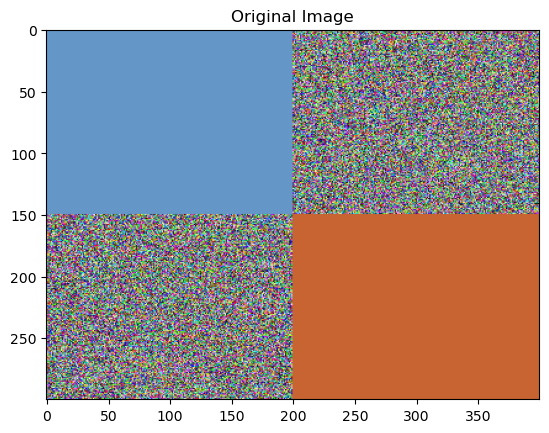

In [ ]:
# Display the loaded image
plt.imshow(image)
plt.title("Original Image")
plt.show()

# Extract the top half of the image

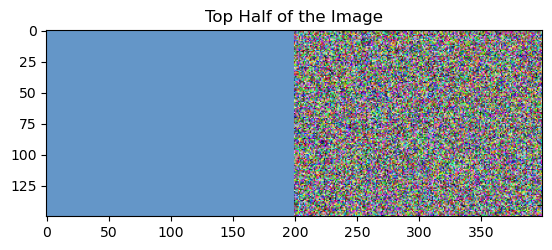

In [ ]:
# Extract the top half of the image
top_half_image = assigner.extract_top_half(image)

# Display the top half
plt.imshow(top_half_image)
plt.title("Top Half of the Image")
plt.show()

# Perform clustering on the image

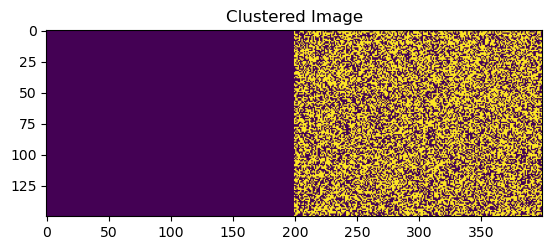

In [ ]:
# Perform clustering
kmeans, clustered_image = assigner.cluster_image(top_half_image)

# Display the clustered image
plt.imshow(clustered_image, cmap="viridis")
plt.title("Clustered Image")
plt.show()

In [ ]:
# Identify the non-player cluster
corner_clusters = [
    clustered_image[0, 0], clustered_image[0, -1],
    clustered_image[-1, 0], clustered_image[-1, -1]
]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(f"Non-player cluster: {non_player_cluster}")

1


In [ ]:
# Identify the player cluster and its color
player_cluster = assigner.get_player_cluster(clustered_image)
player_color = assigner.get_cluster_color(kmeans, player_cluster)

print(f"Player cluster: {player_cluster}")
print(f"Player color (RGB): {player_color}")

0
